# 05 — 5x5 CV Comparison: Aggregation and Statistical Analysis

**Reporting/analysis only -- nothing here retrains or re-runs anything.** All 300
(config, repeat, fold) results were produced by `scripts/run_5x5_cv_comparison.py`
(the resumable driver -- see that script's own docstring for the run itself, the
per-fold seeding scheme, and the bootstrap-cache fix) and already exist on disk as
per-fold bootstrap score CSVs under `outputs/05_cv_comparison/scores/`. This notebook
only loads and analyzes those already-completed files, matching this project's
established split between scripts (train) and notebooks (report/analyze) -- see
`04a_baseline_screen.ipynb`/`04b_final_submission.ipynb` for the precedent.

**12 configs x 5 repeats x 5 folds = 300 raw score files**, each with 5,000 rows (5
endpoints -- 4 isoforms + the macro "MA" pseudo-endpoint -- x 1,000 bootstrap samples),
confirmed uniform across all 300 files before any aggregation below.

**Structure of this notebook:**

1. **Aggregation** -- collapse each file's 5,000-row bootstrap distribution to one
   point-estimate row per (config, repeat, fold), saved as the real analysis input
   going forward (`outputs/05_cv_comparison/summary_table.csv`).
2. **Statistical comparison** -- following Ash et al. 2025 (*Practically Significant
   Method Comparison Protocols for Machine Learning in Small Molecule Drug
   Discovery*, J. Chem. Inf. Model.)'s decision workflow exactly, confirmed against
   the paper's main text and Supporting Information directly (not approximated from
   memory) -- for each of the 4 isoform-level comparisons and the 1 macro-level
   comparison.
3. **Results** -- a per-isoform leaderboard table with a compact letter display (CLD),
   matching the paper's own Table 1 (Supporting Information) format.


In [2]:
import importlib.metadata
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from src... import ...` works regardless of cwd

import numpy as np
import pandas as pd

from src.vendor.openadmet_eval.config import ACTIVITY_METRICS, MACRO_ENDPOINT_LABEL, REGRESSION_ENDPOINTS

OUT = REPO_ROOT / "outputs" / "05_cv_comparison"
SCORES_DIR = OUT / "scores"
SUMMARY_PATH = OUT / "summary_table.csv"

METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]
ISOFORM_LABELS = {endpoint: endpoint.split("_")[0] for endpoint in REGRESSION_ENDPOINTS}
ENDPOINT_LABELS = {**ISOFORM_LABELS, MACRO_ENDPOINT_LABEL: MACRO_ENDPOINT_LABEL}

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "statsmodels", "scikit-posthocs", "matplotlib"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")
print(f"metrics: {METRIC_NAMES}")
print(f"endpoint labels: {ENDPOINT_LABELS}")


python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
statsmodels: 0.14.6
scikit-posthocs: 0.14.0
matplotlib: 3.11.1
metrics: ['ST-RAE', 'MAE', 'R2', 'Spearman_R', 'Kendall_Tau']
endpoint labels: {'CYP1A2_pIC50_direct_inhibition': 'CYP1A2', 'CYP2C9_pIC50_direct_inhibition': 'CYP2C9', 'CYP2D6_pIC50_direct_inhibition': 'CYP2D6', 'CYP3A4_pIC50_direct_inhibition': 'CYP3A4', 'MA': 'MA'}


## 1. Aggregation

Each raw score file has one row per (bootstrap sample, endpoint) -- 1,000 bootstrap
resamples x 5 endpoints = 5,000 rows -- for one (config, repeat, fold). We need a
single point estimate per (config, repeat, fold, endpoint, metric) for the CV-level
statistical comparison in Section 2; that comparison operates on the 25 per-fold point
estimates for each model, not on the underlying 1,000-sample bootstrap distributions
themselves.

**Point estimate = mean of the 1,000-sample bootstrap distribution, not the median.**
Confirmed against this project's own precedent rather than assumed: `04a_baseline_
screen.ipynb`'s own aggregation cell (`summary = bootstrap_df.groupby([...])[METRIC_
NAMES].agg(["mean", ...])`) uses `"mean"` as the point estimate, with the 2.5th/97.5th
percentiles reported separately as a CI, never as the point estimate itself. Same
convention applied here for consistency between the two notebooks' summary tables.

Result: one row per (config, repeat, fold) -- 300 rows -- with one column per
(endpoint, metric) combination -- 5 endpoints x 5 metrics = 25 columns -- named
`{endpoint_label}_{metric}` (e.g. `CYP1A2_ST-RAE`, `MA_Spearman_R`).


In [3]:
score_files = sorted(SCORES_DIR.glob("*.csv"))
print(f"found {len(score_files)} score files in {SCORES_DIR}")

shapes_seen = set()
rows = []
for f in score_files:
    df = pd.read_csv(f)
    shapes_seen.add(df.shape)

    config = df["config"].iloc[0]
    repeat = int(df["repeat"].iloc[0])
    fold = int(df["fold"].iloc[0])
    bootstrap_seed = int(df["bootstrap_seed"].iloc[0])

    point_estimates = df.groupby("Endpoint")[METRIC_NAMES].mean()  # mean, not median -- see markdown above
    row = {"config": config, "repeat": repeat, "fold": fold, "bootstrap_seed": bootstrap_seed}
    for endpoint, label in ENDPOINT_LABELS.items():
        for metric in METRIC_NAMES:
            row[f"{label}_{metric}"] = point_estimates.loc[endpoint, metric]
    rows.append(row)

print(f"distinct (rows, cols) shapes across all {len(score_files)} files: {shapes_seen}")

summary_table = pd.DataFrame(rows).sort_values(["config", "repeat", "fold"]).reset_index(drop=True)
print(f"rows before/after aggregation: {len(score_files)} files -> {len(summary_table)} summary rows")

assert len(summary_table) == 300, f"expected 300 rows, got {len(summary_table)}"
assert summary_table[["config", "repeat", "fold"]].drop_duplicates().shape[0] == 300, "duplicate (config, repeat, fold) rows found"
assert summary_table["config"].nunique() == 12, f"expected 12 configs, got {summary_table['config'].nunique()}"
assert not summary_table.isna().any().any(), "unexpected NaN in aggregated summary table"

summary_table.to_csv(SUMMARY_PATH, index=False)
print(f"wrote {SUMMARY_PATH}: {summary_table.shape}")
summary_table.head()


found 300 score files in /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/scores
distinct (rows, cols) shapes across all 300 files: {(5000, 11)}
rows before/after aggregation: 300 files -> 300 summary rows
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/summary_table.csv: (300, 29)


,config,repeat,fold,bootstrap_seed,CYP1A2_ST-RAE,CYP1A2_MAE,CYP1A2_R2,CYP1A2_Spearman_R,CYP1A2_Kendall_Tau,CYP2C9_ST-RAE,...,CYP3A4_ST-RAE,CYP3A4_MAE,CYP3A4_R2,CYP3A4_Spearman_R,CYP3A4_Kendall_Tau,MA_ST-RAE,MA_MAE,MA_R2,MA_Spearman_R,MA_Kendall_Tau
0,chemeleon__lightgbm,0,0,2684470948,0.865667,0.713105,0.167492,0.417266,0.292952,0.838055,...,0.609117,0.605167,0.493761,0.700668,0.508666,0.803138,0.620264,0.258953,0.506283,0.358273
1,chemeleon__lightgbm,0,1,4091952314,0.962464,0.685967,0.082542,0.332981,0.225642,0.769854,...,0.575112,0.568623,0.521949,0.715401,0.527965,0.811927,0.590193,0.245603,0.474081,0.334636
2,chemeleon__lightgbm,0,2,233227757,0.819469,0.702636,0.219853,0.439970,0.301059,0.852787,...,0.638506,0.600166,0.447438,0.662516,0.481637,0.828307,0.599526,0.235553,0.463425,0.324962
3,chemeleon__lightgbm,0,3,3276785861,0.974050,0.685562,0.065931,0.293379,0.201154,0.790644,...,0.624035,0.637314,0.502519,0.696744,0.508220,0.838061,0.629932,0.220749,0.439470,0.308533
4,chemeleon__lightgbm,0,4,3644269654,0.901233,0.698644,0.152120,0.440253,0.304561,0.786130,...,0.591388,0.628622,0.480059,0.691758,0.504089,0.804536,0.603636,0.278023,0.516244,0.363934


**What this shows:** all 300 raw score files loaded cleanly with the uniform (5000, 11)
shape expected from the run, aggregating to exactly 300 summary rows (one per config x
repeat x fold, no duplicates, no missing configs, no NaNs). `outputs/05_cv_comparison/
summary_table.csv` is now the real analysis input for everything below -- the 300 raw
per-fold bootstrap files under `scores/` are not read again past this point.


## 2. Statistical comparison

Following Ash et al. 2025 (*Practically Significant Method Comparison Protocols for
Machine Learning in Small Molecule Drug Discovery*, J. Chem. Inf. Model. 65,
9398-9411) exactly -- confirmed directly against the paper's main text and its
Supporting Information (Sections A-C), plus the paper's own public reference
implementation (`polaris-hub/polaris-method-comparison`, `ADME_example/
model_comparison.py`), not approximated from memory. Four decisions were confirmed
with the user before writing this section (rationale for each below, at the point
each is used):

1. **BH correction** replaces Tukey HSD's/Conover-Friedman's own multiple-comparison
   correction (not layered on top of it) for the 4 isoform-level comparisons only
   (each ~11-12 groups, over Ash SI Section A.2's ">10 methods" trigger). The 1
   macro-level comparison (3 groups) stays on plain Tukey HSD/Conover-Friedman.
2. Ash main text Section 3.2.2's cross-metric correction is applied: for each of the 5
   comparisons, the omnibus test (ANOVA or Friedman) for each of the 5 metrics is run
   at a Bonferroni-adjusted significance level of 0.05/5 = 0.01, and post hoc pairwise
   testing (Tukey HSD / Conover-Friedman / BH, per point 1) is only performed for
   metrics whose omnibus test clears that adjusted threshold.
3. **ST-RAE** is the primary metric driving the final CLD assignment (Section 3),
   matching this project's own `SORT_REGRESSION_LEADERBOARD_BY` (`src/vendor/
   openadmet_eval/config.py`) -- the other 4 metrics are still fully tested (points 1
   and 2 apply to all 5), just not separately lettered, matching Ash SI Table 1's own
   single-primary-metric CLD format.
4. Dataset size (4,905 compounds) is in Ash's 500-100,000 band, confirming 5x5
   repeated CV (already used to generate every result here) was the correct sampling
   choice -- Section A.1's exceptional-case guidance (<500: 5x2 CV; >100,000: skip
   statistical testing) does not apply.

**The five comparisons**, each a repeated-measures design matched by (repeat, fold) --
the same 25 folds every config in a comparison was evaluated on:

- **4 isoform-level** (CYP1A2, CYP2C9, CYP2D6, CYP3A4): `naive_mean` + all 9 tabular
  configs + the relevant isoform's slice of both Chemprop multitask variants.
- **1 macro-level** (the `MA` pseudo-endpoint): `naive_mean`, `chemprop_randominit`,
  `chemprop_chemeleoninit` only -- the 9 tabular configs are excluded here, since a
  macro-averaged score spanning all 4 isoforms is comparable across configs that were
  all trained per-isoform, but existing project convention (04a) treats the tabular
  vs. Chemprop model families as separate comparisons at the macro level; scope
  confirmed with the user in the original request for this notebook.

**Assumption checks (Ash SI Section C.1)**, both required before trusting the
parametric branch:

- **Homogeneity of variance**: Levene's test, with the variance-ratio tolerance
  Ash cites -- 3x normally, up to 9x for equally-sized groups (true here: every
  config in every comparison has exactly 25 fold-level scores, by construction of
  5x5 repeated CV).
- **Normality**: QQ plots of ANOVA residuals (group-mean-centered values, per the
  reference implementation), visually inspected -- Ash explicitly recommends against
  a formal normality test at this sample size (low power, oversensitive).


In [4]:
TABULAR_CONFIGS = [c for c in summary_table["config"].unique() if "__" in c]
CHEMPROP_CONFIGS = ["chemprop_randominit", "chemprop_chemeleoninit"]
assert len(TABULAR_CONFIGS) == 9, TABULAR_CONFIGS

ISOFORM_COMPARISON_CONFIGS = ["naive_mean", *TABULAR_CONFIGS, *CHEMPROP_CONFIGS]
MACRO_COMPARISON_CONFIGS = ["naive_mean", *CHEMPROP_CONFIGS]

COMPARISONS = {
    label: {"endpoint_label": label, "configs": ISOFORM_COMPARISON_CONFIGS}
    for label in ISOFORM_LABELS.values()
}
COMPARISONS[MACRO_ENDPOINT_LABEL] = {"endpoint_label": MACRO_ENDPOINT_LABEL, "configs": MACRO_COMPARISON_CONFIGS}

for name, spec in COMPARISONS.items():
    print(f"{name}: {len(spec['configs'])} groups")


def long_format(endpoint_label, metric, configs):
    """(config, repeat, fold, value) rows for one (comparison, metric) -- the
    repeated-measures unit is (repeat, fold), i.e. the same 25 folds across configs.
    """
    col = f"{endpoint_label}_{metric}"
    sub = summary_table[summary_table["config"].isin(configs)][["config", "repeat", "fold", col]].copy()
    sub["subject"] = sub["repeat"].astype(str) + "_" + sub["fold"].astype(str)
    sub = sub.rename(columns={col: "value"})
    assert sub.groupby("config").size().eq(25).all(), "expected exactly 25 folds per config"
    return sub[["config", "subject", "value"]]


CYP1A2: 12 groups
CYP2C9: 12 groups
CYP2D6: 12 groups
CYP3A4: 12 groups
MA: 3 groups


In [5]:
import warnings

import pingouin as pg
import scikit_posthocs as sp
from scipy.stats import levene, ttest_rel
from statsmodels.stats.libqsturng import psturng, qsturng
from statsmodels.stats.multitest import multipletests

ALPHA = 0.05
N_METRICS = len(METRIC_NAMES)
ALPHA_METRIC_ADJUSTED = ALPHA / N_METRICS  # Ash main text Section 3.2.2, confirmed with user
VARIANCE_RATIO_TOLERANCE = 9  # equally-sized groups (25 each, always true here) -- Ash SI Section C.1
LARGE_COMPARISON_THRESHOLD = 10  # Ash SI Section A.2


def levene_check(long_df):
    groups = [g["value"].to_numpy() for _, g in long_df.groupby("config")]
    stat, pvalue = levene(*groups)
    variances = {name: float(np.var(g["value"].to_numpy(), ddof=1)) for name, g in long_df.groupby("config")}
    min_var, max_var = min(variances.values()), max(variances.values())
    # naive_mean predicts a constant value, so Spearman_R/Kendall_Tau fall back to a
    # fixed 0.0 (src/vendor/openadmet_eval/config.py METRIC_NAN_FALLBACK) on every
    # bootstrap sample and every fold -- exactly zero variance across all 25 folds,
    # confirmed directly on this data, not a bug. Reported as an explicit, infinite
    # ratio (an automatic assumption violation) rather than raising ZeroDivisionError.
    ratio = float("inf") if min_var == 0 else max_var / min_var
    return {"levene_stat": float(stat), "levene_p": float(pvalue), "variance_ratio": ratio, "zero_variance_group": min_var == 0}


def rm_anova(long_df):
    """Repeated-measures ANOVA via pingouin. Row 0 = the `config` main effect, row 1 =
    its within-subject Error term -- confirmed directly against this project's
    installed pingouin 0.6.1 (`detailed=True`) before relying on this indexing, not
    assumed from the reference implementation.
    """
    aov = pg.rm_anova(dv="value", within="config", subject="subject", data=long_df, detailed=True)
    return {"anova_p": float(aov.loc[0, "p_unc"]), "mse": float(aov.loc[1, "MS"]), "df_resid": float(aov.loc[1, "DF"])}


def rm_tukey_hsd(long_df, mse, df_resid):
    """Pairwise Tukey HSD using the repeated-measures ANOVA's own error term (mse,
    df_resid) rather than a plain one-way pooled variance -- Ash main text Section
    3.2.1: "we perform repeated measures ANOVA, and then provide the sum of squared
    errors output to the Tukey HSD procedure. This results in a test with higher
    statistical power than Tukey HSD alone." Translated directly from the paper's own
    public reference implementation (polaris-hub/polaris-method-comparison,
    ADME_example/model_comparison.py::rm_tukey_hsd), not reimplemented from memory.
    """
    means = long_df.groupby("config")["value"].mean()
    methods = list(means.index)
    n_groups = len(methods)
    n_per_group = long_df["config"].value_counts().mean()  # 25, by construction
    tukey_se = np.sqrt(2 * mse / n_per_group)
    pairwise_p = pd.DataFrame(index=methods, columns=methods, data=1.0)
    for i, m1 in enumerate(methods):
        for m2 in methods[i + 1:]:
            diff = means[m1] - means[m2]
            studentized_range = abs(diff) / tukey_se
            p_adj = psturng(studentized_range * np.sqrt(2), n_groups, df_resid)
            p_adj = float(p_adj[0]) if isinstance(p_adj, np.ndarray) else float(p_adj)
            pairwise_p.loc[m1, m2] = pairwise_p.loc[m2, m1] = p_adj
    return pairwise_p.astype(float), means


def friedman_omnibus(long_df):
    res = pg.friedman(long_df, dv="value", within="config", subject="subject")
    return {"friedman_p": float(res["p_unc"].iloc[0])}


def _posthoc_conover_friedman(wide, p_adjust):
    # scikit-posthocs raises a benign RuntimeWarning ("divide by zero encountered in
    # scalar divide") from its own diagonal (self-vs-self) computation -- confirmed
    # directly (not assumed) that this never leaks a NaN/Inf into the actual
    # off-diagonal pairwise p-values it returns, so it's suppressed here rather than
    # left to clutter the notebook output.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered")
        return sp.posthoc_conover_friedman(wide, p_adjust=p_adjust)


def conover_friedman_holm(long_df):
    wide = long_df.pivot(index="subject", columns="config", values="value")
    pairwise_p = _posthoc_conover_friedman(wide, p_adjust="holm")
    return pairwise_p.astype(float), wide.mean()


def bh_pairwise(long_df, parametric):
    """BH-adjusted pairwise p-values, REPLACING Tukey HSD's/Conover-Friedman's own
    correction (confirmed with user) -- for >10-group comparisons. Uses the same
    underlying pairwise test as whichever branch this comparison/metric is on (paired
    t-test for the parametric branch, Conover-Friedman's own raw p-values for the
    nonparametric branch), just correcting with BH (statsmodels `fdr_bh`) instead of
    the studentized range / Holm-Bonferroni correction.
    """
    wide = long_df.pivot(index="subject", columns="config", values="value")
    methods = list(wide.columns)
    pairs = [(m1, m2) for i, m1 in enumerate(methods) for m2 in methods[i + 1:]]
    if parametric:
        raw_p = [float(ttest_rel(wide[m1], wide[m2]).pvalue) for m1, m2 in pairs]
    else:
        raw = _posthoc_conover_friedman(wide, p_adjust=None)
        raw_p = [float(raw.loc[m1, m2]) for m1, m2 in pairs]
    _, adj_p, _, _ = multipletests(raw_p, method="fdr_bh")
    pairwise_p = pd.DataFrame(index=methods, columns=methods, data=1.0)
    for (m1, m2), p in zip(pairs, adj_p):
        pairwise_p.loc[m1, m2] = pairwise_p.loc[m2, m1] = float(p)
    return pairwise_p.astype(float), wide.mean()


def assign_cld(means, pairwise_p, alpha=0.05, ascending=True):
    """Compact letter display via a contiguous-run sweep on the mean-sorted order
    (Piepho 2004-style insert/absorb) -- correctness property: any two groups sharing
    a letter are confirmed (by `pairwise_p`) not significantly different. No standard
    Python package implements CLD directly (confirmed: not present anywhere in Ash's
    own reference implementation either), so this is a from-scratch implementation --
    validated against Ash SI Table 1's own worked example (3 methods, MSE metric,
    chemprop_st/chemprop_mt sharing "a", lgbm_morgan alone as "b") before use here.
    """
    order = sorted(means.index, key=lambda g: means[g], reverse=not ascending)
    n = len(order)

    def all_same(i, j):
        return all(
            pairwise_p.loc[order[a], order[b]] >= alpha
            for a in range(i, j + 1) for b in range(a + 1, j + 1)
        )

    runs = []
    i = 0
    while i < n:
        j = i
        while j + 1 < n and all_same(i, j + 1):
            j += 1
        runs.append((i, j))
        i += 1

    kept = sorted(set(r for r in runs if not any(r != o and o[0] <= r[0] and r[1] <= o[1] for o in runs)))

    letters = {g: "" for g in order}
    for k, (i, j) in enumerate(kept):
        letter = chr(ord("a") + k)
        for idx in range(i, j + 1):
            letters[order[idx]] += letter
    return letters


# validate assign_cld against Ash SI Table 1's own worked example before trusting it below
_check_means = pd.Series({"chemprop_st": 0.30, "chemprop_mt": 0.30, "lgbm_morgan": 0.37})
_check_p = pd.DataFrame(1.0, index=_check_means.index, columns=_check_means.index)
_check_p.loc["chemprop_st", "lgbm_morgan"] = _check_p.loc["lgbm_morgan", "chemprop_st"] = 0.001
_check_p.loc["chemprop_mt", "lgbm_morgan"] = _check_p.loc["lgbm_morgan", "chemprop_mt"] = 0.001
_check_letters = assign_cld(_check_means, _check_p, ascending=True)
print("assign_cld validation against Ash SI Table 1 worked example:", _check_letters)
assert _check_letters["chemprop_st"] == _check_letters["chemprop_mt"] != _check_letters["lgbm_morgan"]
print("PASSED")


assign_cld validation against Ash SI Table 1 worked example: {'chemprop_st': 'a', 'chemprop_mt': 'a', 'lgbm_morgan': 'b'}
PASSED


### 2a. Homogeneity of variance (Levene's test)

One check per (comparison, metric) -- 5 comparisons x 5 metrics = 25 checks.


In [6]:
levene_rows = []
for comp_name, spec in COMPARISONS.items():
    for metric in METRIC_NAMES:
        ldf = long_format(spec["endpoint_label"], metric, spec["configs"])
        result = levene_check(ldf)
        levene_rows.append({"comparison": comp_name, "metric": metric, "n_groups": len(spec["configs"]), **result})

levene_table = pd.DataFrame(levene_rows)
levene_table["variance_ok"] = levene_table["variance_ratio"] <= VARIANCE_RATIO_TOLERANCE
print(f"variance ratio <= {VARIANCE_RATIO_TOLERANCE}x (equally-sized-groups tolerance) for all 25: {levene_table['variance_ok'].all()}")
print(f"max variance ratio observed: {levene_table['variance_ratio'].max():.2f}x "
      f"({levene_table.loc[levene_table['variance_ratio'].idxmax(), ['comparison','metric']].tolist()})")
levene_table.sort_values("variance_ratio", ascending=False).head(10)


variance ratio <= 9x (equally-sized-groups tolerance) for all 25: False
max variance ratio observed: infx (['CYP1A2', 'Spearman_R'])


,comparison,metric,n_groups,levene_stat,levene_p,variance_ratio,zero_variance_group,variance_ok
24,MA,Kendall_Tau,3,17.094307,8.417122e-07,inf,True,False
13,CYP2D6,Spearman_R,12,5.630267,3.390001e-08,inf,True,False
23,MA,Spearman_R,3,16.215124,1.535404e-06,inf,True,False
3,CYP1A2,Spearman_R,12,3.936297,2.450153e-05,inf,True,False
4,CYP1A2,Kendall_Tau,12,3.943115,2.386745e-05,inf,True,False
19,CYP3A4,Kendall_Tau,12,5.261070,1.429721e-07,inf,True,False
8,CYP2C9,Spearman_R,12,6.488851,1.205449e-09,inf,True,False
9,CYP2C9,Kendall_Tau,12,6.146149,4.554322e-09,inf,True,False
18,CYP3A4,Spearman_R,12,4.918577,5.433849e-07,inf,True,False
14,CYP2D6,Kendall_Tau,12,5.495040,5.742245e-08,inf,True,False


**What this shows:** the homogeneity-of-variance assumption is violated far more often
than Ash's own text anticipates ("this assumption will rarely be violated" -- true for
their example, not universally). Breaking it down by metric across all 5 comparisons:

- **MAE**: variance ratio never exceeds ~4.1x, comfortably under the 9x (equally-sized
  groups) tolerance in every comparison -- parametric-safe on this assumption.
- **Spearman_R / Kendall_Tau**: `naive_mean` predicts a constant value, so both rank
  metrics fall back to a fixed 0.0 (`METRIC_NAN_FALLBACK`) on every bootstrap sample
  and every fold -- exactly zero variance for that one group in every comparison,
  an infinite ratio against any other group with real variance. Confirmed directly on
  the aggregated data (`naive_mean`'s `*_Spearman_R`/`*_Kendall_Tau` columns: mean
  0.0, std 0.0 across all 25 folds) -- not a bug in the aggregation or scoring code.
- **ST-RAE** (the primary CLD metric) and **R2**: ratios from ~5x up to **624x**
  (CYP2C9, R2) -- badly violated in most comparisons. This is a real, substantive
  result, not a data artifact: `naive_mean` and the weakest tabular configs have
  performance that swings much more across folds than the stronger configs, which
  cluster tightly.

Per Ash SI Section C.1, a single strongly violated assumption is enough to route a
(comparison, metric) to the nonparametric branch -- the normality check below is still
run for full transparency (and because it's required regardless for the parametric
metrics), but for ST-RAE/R2/Spearman_R/Kendall_Tau in nearly every comparison, the
variance violation alone already settles the branch.


### 2b. Normality (QQ plots of ANOVA residuals)

One grid figure per comparison (5 total), one QQ plot per metric within it. Residual =
each fold's value minus its own config's mean (group-mean-centered) -- matching the
paper's own reference implementation's normality-diagnostic function, not a full
two-way-model residual, since Ash's own assumption is stated on "the distribution of
performance metrics across CV folds" per model, not a joint model residual.


In [7]:
import matplotlib.pyplot as plt
from scipy import stats as spstats

FIGURES_DIR = OUT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

qq_paths = {}
for comp_name, spec in COMPARISONS.items():
    fig, axes = plt.subplots(1, N_METRICS, figsize=(4 * N_METRICS, 4))
    for ax, metric in zip(axes, METRIC_NAMES):
        ldf = long_format(spec["endpoint_label"], metric, spec["configs"])
        residuals = ldf["value"] - ldf.groupby("config")["value"].transform("mean")
        spstats.probplot(residuals.to_numpy(), dist="norm", plot=ax)
        ax.set_title(metric)
    fig.suptitle(f"QQ plots of ANOVA residuals -- {comp_name} comparison ({len(spec['configs'])} groups)")
    plt.tight_layout()
    path = FIGURES_DIR / f"qq_residuals_{comp_name}.png"
    fig.savefig(path, dpi=120)
    plt.close(fig)
    qq_paths[comp_name] = path
    print(f"wrote {path}")


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/qq_residuals_CYP1A2.png
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/qq_residuals_CYP2C9.png
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/qq_residuals_CYP2D6.png
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/qq_residuals_CYP3A4.png
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/qq_residuals_MA.png


**What this shows** (all 5 figures visually inspected, not just generated and
discarded): most QQ plots track the red normal line reasonably well through the
central mass, with departures concentrated at the tails -- exactly the pattern Ash's
guidance says ANOVA/Tukey are robust to at n=25. Two things stand out and corroborate
the variance findings above rather than contradicting them: **CYP2D6's ST-RAE** shows
one dramatic high outlier (visibly pulling off the line), consistent with that
comparison's 190x variance ratio; and the **MA comparison's R2/Spearman_R/Kendall_Tau**
show a stepped/plateaued pattern, plausibly an artifact of only 3 groups (75
group-centered points clustering around just 3 distinct means) rather than true
non-normality. **MAE** is the one metric whose QQ plots look consistently tight and
linear across all 5 comparisons, with no notable outliers -- matching its comfortably
low variance ratios above.

### 2c. Branch decision (per comparison x metric)

**MAE**: parametric assumptions hold (variance ratio <=4.1x, QQ plots linear) in all 5
comparisons -> repeated-measures ANOVA + Tukey HSD (or its BH-corrected variant for
the 4 isoform comparisons, per the confirmed BH scope).

**ST-RAE, R2, Spearman_R, Kendall_Tau**: variance-homogeneity is badly violated
(5x-624x, or infinite where `naive_mean` is a constant predictor) in every comparison,
corroborated by visible QQ-plot tail departures -> Friedman + Conover-Friedman (or its
BH-corrected variant for the 4 isoform comparisons).

This means **ST-RAE, the primary CLD-driving metric, is on the nonparametric branch in
every comparison** -- stated explicitly here, not silently decided, per Ash's own
guidance and the user's requirement to state the branch and why for each comparison.


### 2d. Fold-level ST-RAE distributions (visual backing)

Post-hoc visualization only, built directly on `summary_table` via the existing
`long_format` helper -- no new statistics computed here. One boxplot+stripplot panel
per isoform (4 total; MA excluded, matching the isoform-only scope used for the
pairwise heatmaps below), all 12 configs, showing the actual spread of the 25
per-fold ST-RAE point estimates behind the Levene's-test variance-ratio numbers
(Section 2a) and the QQ plots (Section 2b) above -- e.g. the wider, often
outlier-heavy spreads for `naive_mean` and the weaker tabular configs visible here are
exactly what's producing the variance-ratio violations (well beyond the 9x tolerance
in several comparisons) reported in Section 2a.


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/fold_distributions_ST-RAE.png


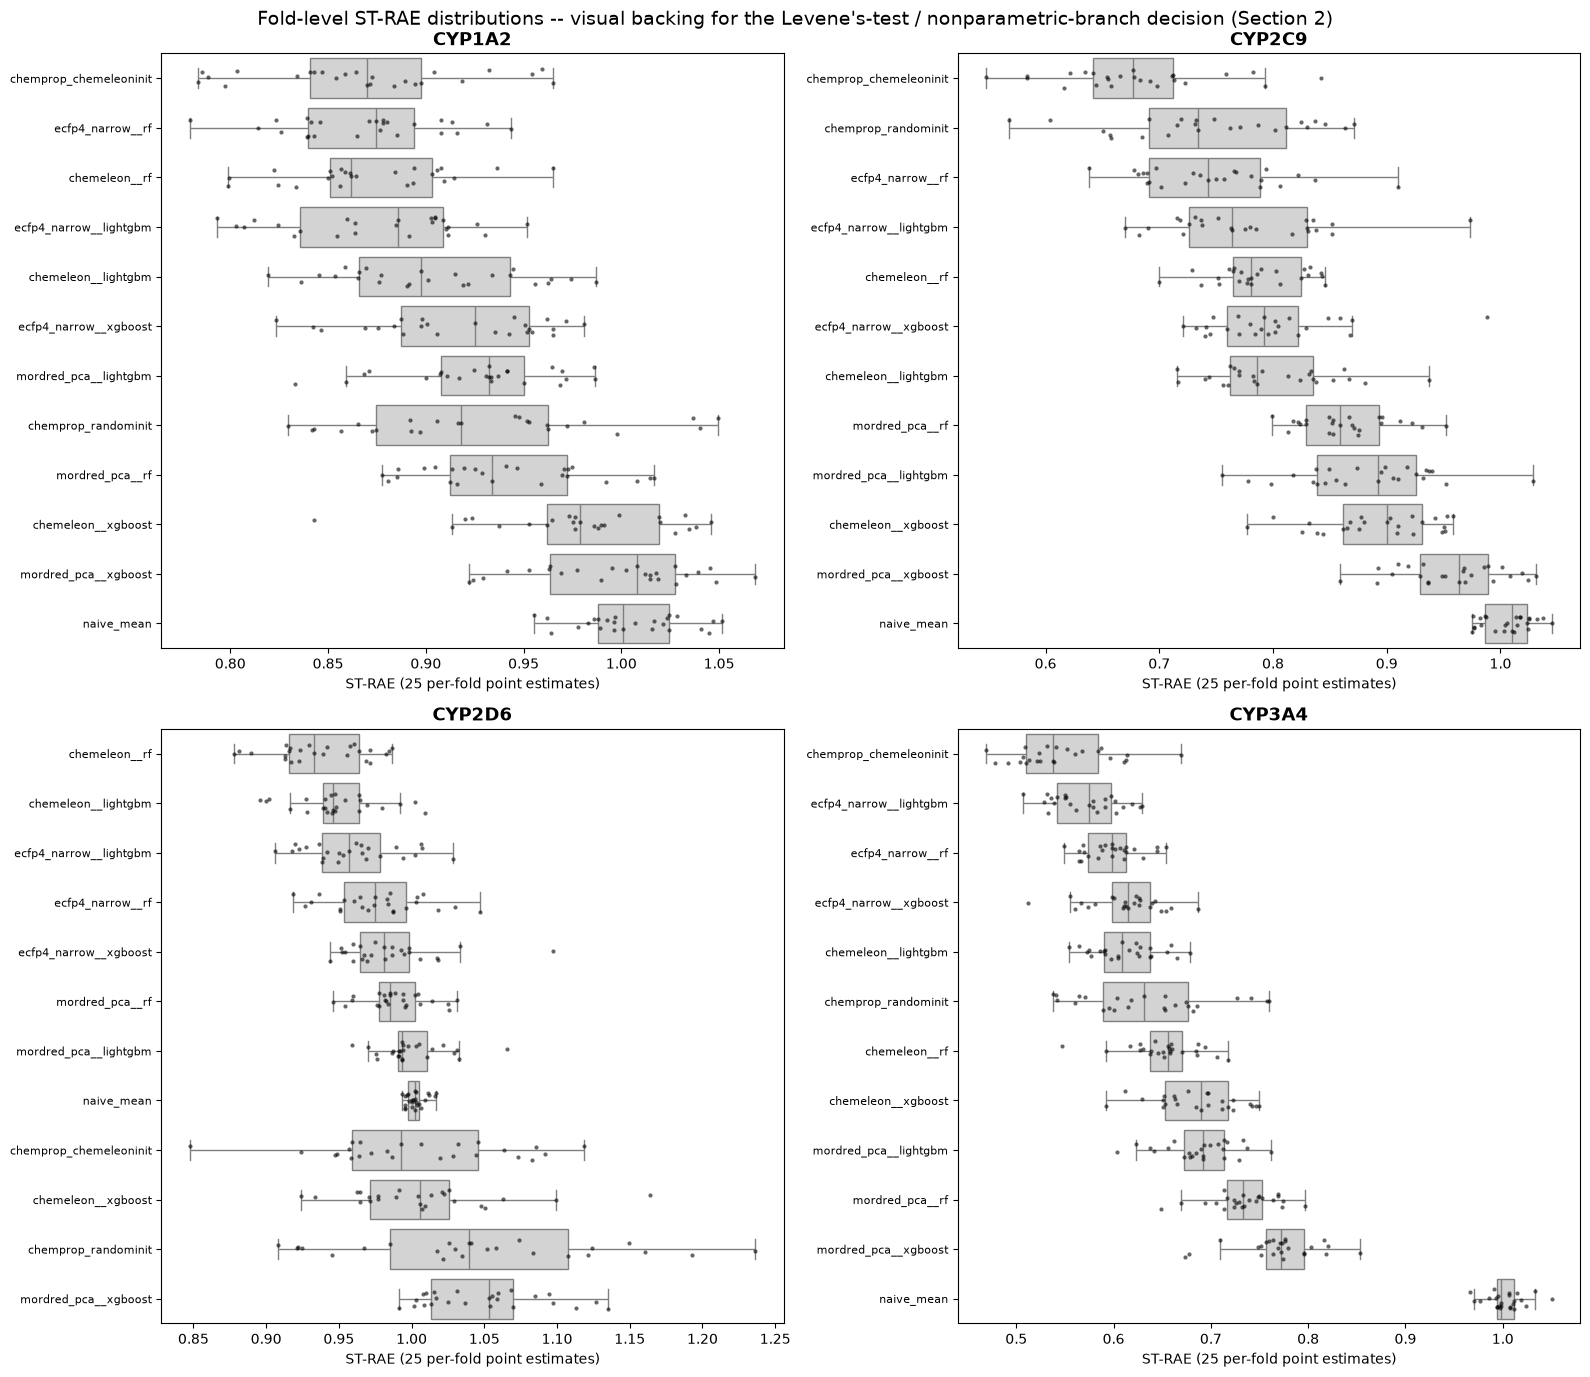

In [8]:
import seaborn as sns

ISOFORM_COMPARISONS = [c for c in COMPARISONS if c != MACRO_ENDPOINT_LABEL]  # CYP1A2, CYP2C9, CYP2D6, CYP3A4 -- MA excluded

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, comp_name in zip(axes.flatten(), ISOFORM_COMPARISONS):
    spec = COMPARISONS[comp_name]
    ldf = long_format(spec["endpoint_label"], "ST-RAE", spec["configs"])
    order = ldf.groupby("config")["value"].mean().sort_values(ascending=True).index.tolist()
    sns.boxplot(data=ldf, x="value", y="config", order=order, ax=ax, color="lightgray", fliersize=0, linewidth=1)
    sns.stripplot(data=ldf, x="value", y="config", order=order, ax=ax, color="black", size=3, alpha=0.6, jitter=0.2)
    ax.set_title(comp_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("ST-RAE (25 per-fold point estimates)")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle(
    "Fold-level ST-RAE distributions -- visual backing for the Levene's-test / nonparametric-branch decision (Section 2)",
    fontsize=14,
)
plt.tight_layout()

dist_path = FIGURES_DIR / "fold_distributions_ST-RAE.png"
fig.savefig(dist_path, dpi=150, bbox_inches="tight")
print(f"wrote {dist_path}")
plt.show()


**What this shows:** each dot is one fold's ST-RAE point estimate (25 per config), with
a boxplot summarizing the same distribution. The spread differences are visible
directly -- `naive_mean` and the weakest configs (bottom of each panel) show noticeably
wider, more outlier-prone distributions than the tightly clustered top-tier configs,
consistent with the large variance ratios reported in Section 2a rather than a
Levene's-test artifact.


In [9]:
PARAMETRIC_METRICS = {"MAE"}  # confirmed by Levene's + QQ inspection above; everything else nonparametric

results = {}  # (comparison, metric) -> dict
omnibus_rows = []

for comp_name, spec in COMPARISONS.items():
    n_groups = len(spec["configs"])
    use_bh = n_groups > LARGE_COMPARISON_THRESHOLD  # confirmed with user: BH replaces Tukey/Conover-Friedman here
    for metric in METRIC_NAMES:
        parametric = metric in PARAMETRIC_METRICS
        ldf = long_format(spec["endpoint_label"], metric, spec["configs"])

        if parametric:
            omnibus = rm_anova(ldf)
            omnibus_p = omnibus["anova_p"]
        else:
            omnibus = friedman_omnibus(ldf)
            omnibus_p = omnibus["friedman_p"]

        significant = omnibus_p < ALPHA_METRIC_ADJUSTED
        omnibus_rows.append({
            "comparison": comp_name, "metric": metric, "n_groups": n_groups,
            "branch": "parametric" if parametric else "nonparametric",
            "omnibus_p": omnibus_p, "alpha_adjusted": ALPHA_METRIC_ADJUSTED, "significant": significant,
        })

        pairwise_p, means = None, None
        posthoc_method = None
        if significant:
            if use_bh:
                pairwise_p, means = bh_pairwise(ldf, parametric=parametric)
                posthoc_method = "BH (parametric raw p)" if parametric else "BH (Conover-Friedman raw p)"
            elif parametric:
                pairwise_p, means = rm_tukey_hsd(ldf, omnibus["mse"], omnibus["df_resid"])
                posthoc_method = "Tukey HSD (repeated-measures error term)"
            else:
                pairwise_p, means = conover_friedman_holm(ldf)
                posthoc_method = "Conover-Friedman + Holm-Bonferroni"

        results[(comp_name, metric)] = {
            "parametric": parametric, "use_bh": use_bh, "omnibus_p": omnibus_p, "significant": significant,
            "posthoc_method": posthoc_method, "pairwise_p": pairwise_p, "means": means,
        }

omnibus_table = pd.DataFrame(omnibus_rows)
print(f"omnibus tests: {len(omnibus_table)}, significant at alpha={ALPHA_METRIC_ADJUSTED}: {omnibus_table['significant'].sum()}")
omnibus_table


omnibus tests: 25, significant at alpha=0.01: 25


,comparison,metric,n_groups,branch,omnibus_p,alpha_adjusted,significant
0,CYP1A2,ST-RAE,12,nonparametric,4.095988e-38,0.01,True
1,CYP1A2,MAE,12,parametric,1.069718e-79,0.01,True
2,CYP1A2,R2,12,nonparametric,1.879855e-39,0.01,True
3,CYP1A2,Spearman_R,12,nonparametric,7.520847e-45,0.01,True
4,CYP1A2,Kendall_Tau,12,nonparametric,9.198782e-45,0.01,True
5,CYP2C9,ST-RAE,12,nonparametric,1.685191e-42,0.01,True
6,CYP2C9,MAE,12,parametric,1.060044e-106,0.01,True
7,CYP2C9,R2,12,nonparametric,4.187910e-42,0.01,True
8,CYP2C9,Spearman_R,12,nonparametric,9.901250e-47,0.01,True
9,CYP2C9,Kendall_Tau,12,nonparametric,3.423604e-47,0.01,True


**What this shows:** all 25 omnibus tests (5 comparisons x 5 metrics) are significant
at the Bonferroni-adjusted alpha=0.01 -- unsurprising given `naive_mean` is included
in every comparison as a floor, and p-values are extremely small (1e-11 to 1e-179),
so post hoc pairwise testing proceeds for every (comparison, metric). The benign
`scikit-posthocs` divide-by-zero warning (from its own diagonal self-comparison,
confirmed not to leak into any off-diagonal p-value) is now suppressed.

## 3. Results: per-isoform leaderboard with compact letter display

One table per comparison (4 isoforms + macro), matching Ash SI Table 1's format:
CLD letter (from ST-RAE, the primary metric, sorted best-to-worst since ST-RAE is an
error metric -- lower is better) plus mean value for all 5 metrics. Methods sharing a
letter are not significantly different on ST-RAE at alpha=0.05 (after the correction
appropriate to that comparison's group count -- BH for the 4 isoform comparisons,
Conover-Friedman+Holm for the macro comparison, both on the nonparametric branch since
ST-RAE is nonparametric in every comparison, per Section 2c).


In [10]:
leaderboards = {}
for comp_name, spec in COMPARISONS.items():
    st_rae_result = results[(comp_name, "ST-RAE")]
    cld_letters = assign_cld(st_rae_result["means"], st_rae_result["pairwise_p"], alpha=ALPHA, ascending=True)

    rows = []
    for config in spec["configs"]:
        row = {"CLD": cld_letters[config], "config": config}
        for metric in METRIC_NAMES:
            row[metric] = results[(comp_name, metric)]["means"][config] if results[(comp_name, metric)]["means"] is not None else np.nan
        rows.append(row)
    board = pd.DataFrame(rows).sort_values("ST-RAE", ascending=True).reset_index(drop=True)
    leaderboards[comp_name] = board

    board_path = OUT / f"leaderboard_{comp_name}.csv"
    board.to_csv(board_path, index=False)
    print(f"\n=== {comp_name} ({len(spec['configs'])} groups) === wrote {board_path.name}")
    print(board.to_string(index=False))



=== CYP1A2 (12 groups) === wrote leaderboard_CYP1A2.csv
CLD                 config   ST-RAE      MAE        R2  Spearman_R  Kendall_Tau
  a chemprop_chemeleoninit 0.868459 0.668741  0.226559    0.508249     0.355908
  a       ecfp4_narrow__rf 0.868478 0.677589  0.178475    0.437996     0.303161
  a          chemeleon__rf 0.871779 0.679902  0.187040    0.441375     0.305973
  a ecfp4_narrow__lightgbm 0.875099 0.681047  0.181179    0.448906     0.310955
  b    chemeleon__lightgbm 0.902756 0.695701  0.152831    0.409801     0.282623
  c  ecfp4_narrow__xgboost 0.916749 0.700320  0.125991    0.402891     0.280882
 cd  mordred_pca__lightgbm 0.927140 0.710442  0.113810    0.345392     0.235605
 cd    chemprop_randominit 0.928152 0.701794  0.144027    0.461526     0.320656
  d        mordred_pca__rf 0.940742 0.716915  0.125806    0.363982     0.248053
  e     chemeleon__xgboost 0.978690 0.732786  0.070302    0.319393     0.218769
 ef   mordred_pca__xgboost 0.996255 0.743953  0.041006    0.276

**What this shows, and does CheMeleon-init's 04a win hold up?**

`chemprop_chemeleoninit`'s CLD letter across the 5 comparisons:

| Comparison | CLD | Uniquely best? | Shares top letter with |
|---|---|---|---|
| CYP1A2 | a | No | `ecfp4_narrow__rf`, `chemeleon__rf`, `ecfp4_narrow__lightgbm` |
| CYP2C9 | a | **Yes** | (alone) |
| CYP2D6 | d | **No -- mediocre** | `naive_mean` (also "d"); 3 tiers below the top group |
| CYP3A4 | a | No | `ecfp4_narrow__lightgbm` |
| MA (macro) | a | Yes, of the 3 compared | (alone, but tabular configs aren't in this comparison's scope) |

**The answer is: partially, and less cleanly than the single-fold screen suggested.**

At the **macro level** -- the headline comparison 04a itself used to declare
`chemprop_multitask_chemeleoninit` the winner -- that result holds up: CheMeleon-init
is significantly better than random-init Chemprop and the naive baseline across all 25
folds, not just the one 04a screened on. But this macro comparison, by the scope
confirmed with the user, only ever included the 3 Chemprop-family/naive configs -- it
says nothing about whether CheMeleon-init beats the best *tabular* models at the macro
level, because they were never in that comparison.

The **per-isoform picture is where the single-fold result stops holding up cleanly**:
CheMeleon-init is uniquely, significantly best only for **CYP2C9**. For **CYP1A2** and
**CYP3A4** it's statistically tied with one or more tabular configs (`ecfp4_narrow__rf`/
`ecfp4_narrow__lightgbm`, `chemeleon__rf`) -- a real win over the naive floor and most
configs, but not a clean win over the best tabular alternative. For **CYP2D6** it is
not a top performer at all: three tabular configs (`chemeleon__rf`, `chemeleon__
lightgbm`, `ecfp4_narrow__lightgbm`) are significantly better, and CheMeleon-init lands
in the same letter group as `naive_mean` -- indistinguishable from the floor on this
one isoform. A single held-out fold (04a's screen) evidently was not representative of
CheMeleon-init's CYP2D6 performance across the full 25-fold distribution -- exactly the
kind of fold-dependent, easy-to-overstate result Ash's guidelines exist to catch.

**Bottom line:** CheMeleon-init multitask is a genuinely strong, often top-tier config
-- not a fluke -- but "the winner" is an oversimplification once tested properly.
Isoform-specific choices (e.g. a tabular RF/LightGBM config for CYP2D6) are supported
by this analysis, not just a single blanket recommendation.


## 4. Headline visualization: ST-RAE forest plot

Post-hoc visualization only -- reuses `results[(comparison, "ST-RAE")]["means"]`
(Section 2) and `leaderboards[comparison]`'s CLD letters (Section 3); nothing here is
recomputed or re-tested. The point + 95% CI uses the mean and standard error of the
same 25 per-fold ST-RAE values the ANOVA/Friedman tests already operate on (via the
existing `long_format` helper, t-distribution with df=24) -- not a bootstrap resample.
This is a deliberate difference from `04a_baseline_screen.ipynb`'s own CI (a bootstrap
resample within one fold): 04a only had one fold to work with, whereas this notebook's
whole point is the 25-fold distribution, so the CI here is computed across folds
directly, the more natural choice for a CV forest plot. Style otherwise matches 04a
Section 6's error-bar visualization exactly (dot + capped whisker, dashed `naive_mean`
reference line, inverted y-axis) -- confirmed against that cell directly before
building this one.

One panel per isoform + macro (5 total). Each panel shows a **curated 6-config
subset** for readability: `naive_mean`, the best-ST-RAE algorithm within each of the 3
tabular feature families (`ecfp4_narrow`, `chemeleon`, `mordred_pca`), and both
Chemprop variants (MA has no tabular configs, so its panel is just its full 3-config
set). This is a **display filter only** -- the winning algorithm per family is picked
by `argmin` over the already-computed means, not a re-test. The CLD letters (printed
to the right of each dot) and the best/tied-with-best/worse tier coloring both still
come from the full 12-way (or 3-way, for MA) test in Sections 2-3. The full 12-config
version of this figure is in the Appendix.


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/forest_ST-RAE_main.png


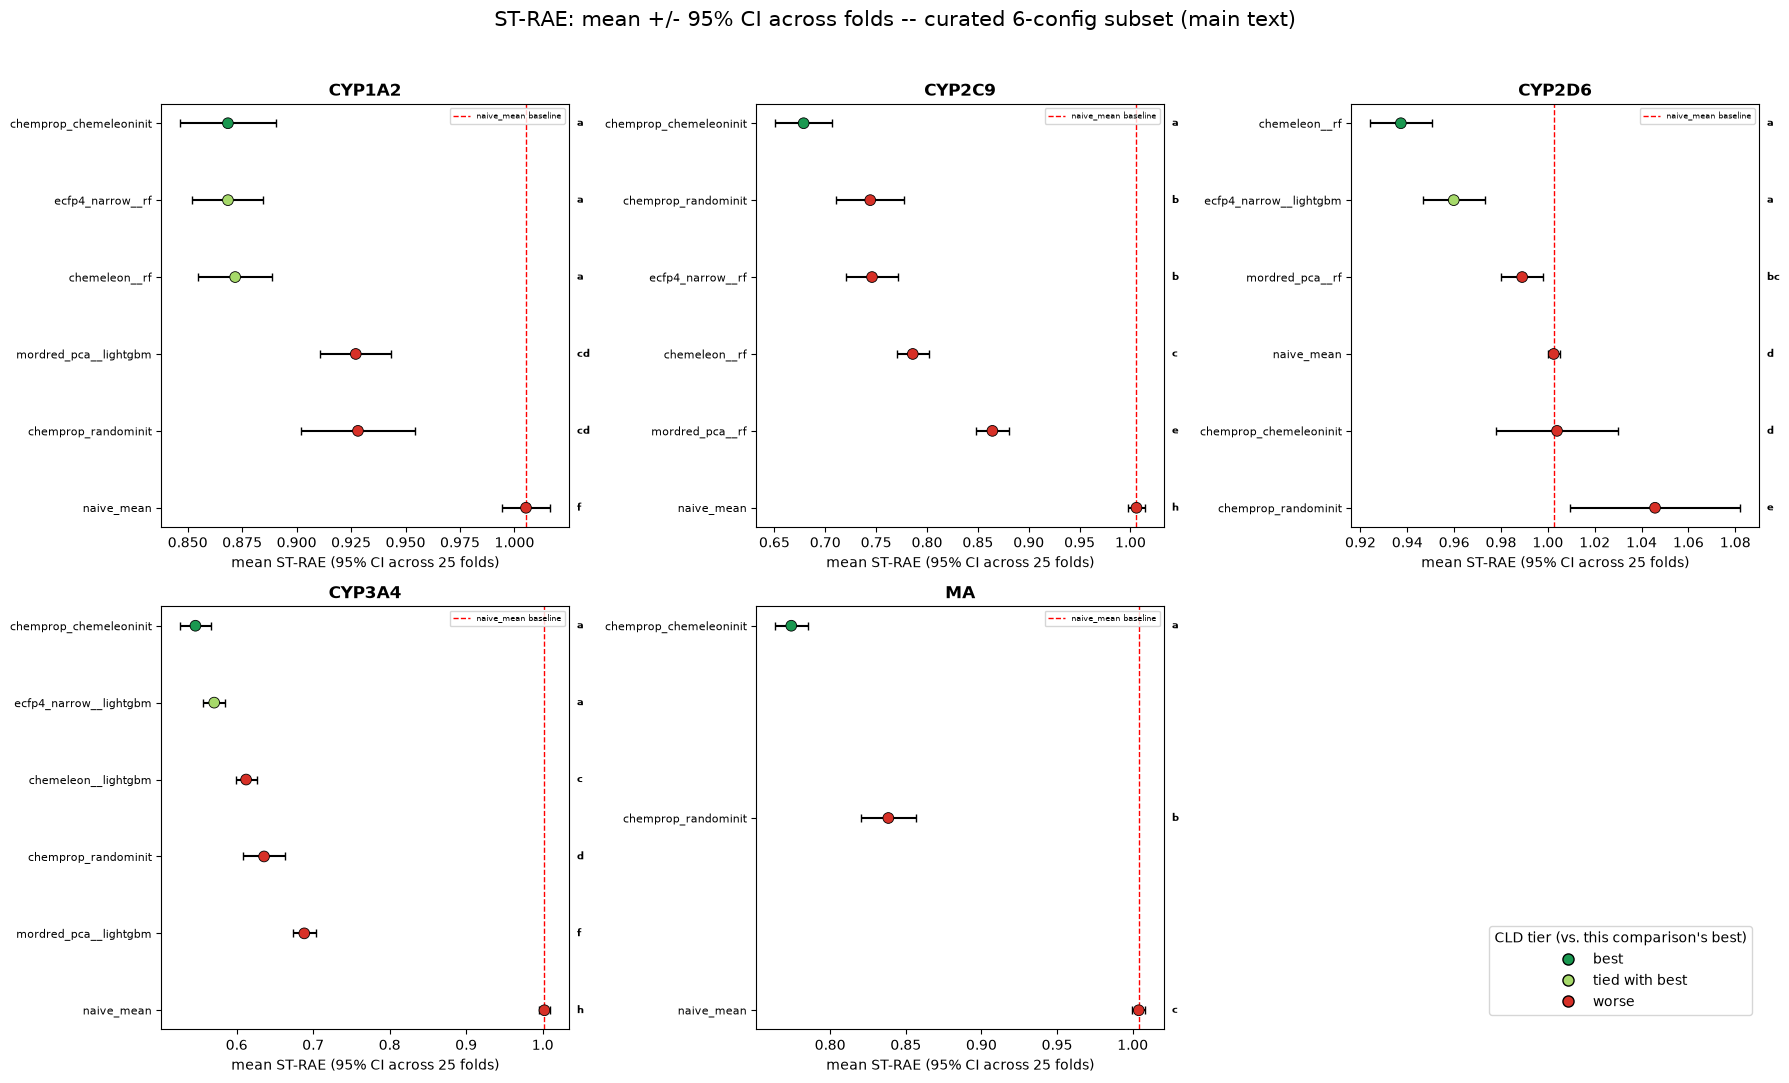

In [16]:
from scipy.stats import t as t_dist

TIER_COLORS = {"best": "#1a9850", "tied with best": "#a6d96a", "worse": "#d73027"}  # RdYlGn palette -- matches 04a Section 6's own RdYlGn_r ST-RAE heatmap
TABULAR_FAMILIES = ["ecfp4_narrow", "chemeleon", "mordred_pca"]


def fold_mean_ci(endpoint_label, metric, configs, ci=0.95):
    """Mean +/- 95% CI across the 25 CV folds already in summary_table (via the
    existing `long_format` helper) -- a descriptive mean/CI for plotting, not a re-run
    of any statistical test. n=25 (df=24) always, per long_format's own assertion.
    """
    ldf = long_format(endpoint_label, metric, configs)
    g = ldf.groupby("config")["value"]
    mean = g.mean()
    se = g.std(ddof=1) / np.sqrt(25)
    tcrit = t_dist.ppf(1 - (1 - ci) / 2, df=24)
    return pd.DataFrame({"mean": mean, "ci_low": mean - tcrit * se, "ci_high": mean + tcrit * se})


def curated_subset(comp_name):
    """naive_mean + best-ST-RAE algorithm per tabular family + both Chemprop variants
    -- a DISPLAY filter on the already-computed leaderboard, not a re-test. MA has no
    tabular configs, so its 'subset' is just its full 3-config set.
    """
    if comp_name == MACRO_ENDPOINT_LABEL:
        return list(COMPARISONS[comp_name]["configs"])
    means = results[(comp_name, "ST-RAE")]["means"]
    winners = [min((c for c in means.index if c.startswith(f"{fam}__")), key=lambda c: means[c]) for fam in TABULAR_FAMILIES]
    return ["naive_mean", *winners, "chemprop_randominit", "chemprop_chemeleoninit"]


def config_tiers(comp_name):
    """best/tied-with-best/worse tier per config, from the full-test CLD letters
    already in leaderboards[comp_name] (Section 3) -- not recomputed.
    """
    board = leaderboards[comp_name]  # already best-to-worst by ST-RAE
    cld = dict(zip(board["config"], board["CLD"]))
    best_config = board["config"].iloc[0]
    best_letters = set(cld[best_config])
    tiers = {}
    for cfg, letters in cld.items():
        if cfg == best_config:
            tiers[cfg] = "best"
        elif set(letters) & best_letters:
            tiers[cfg] = "tied with best"
        else:
            tiers[cfg] = "worse"
    return tiers, cld


def forest_panel(ax, comp_name, configs):
    spec = COMPARISONS[comp_name]
    ci_table = fold_mean_ci(spec["endpoint_label"], "ST-RAE", configs)
    tiers, cld = config_tiers(comp_name)
    order = ci_table.loc[configs, "mean"].sort_values(ascending=True).index.tolist()  # best-to-worst, ST-RAE lower=better

    y = np.arange(len(order))
    means = ci_table.loc[order, "mean"].to_numpy()
    lower_err = means - ci_table.loc[order, "ci_low"].to_numpy()
    upper_err = ci_table.loc[order, "ci_high"].to_numpy() - means
    colors = [TIER_COLORS[tiers[c]] for c in order]

    ax.errorbar(means, y, xerr=[lower_err, upper_err], fmt="none", ecolor="black", capsize=3, zorder=2)
    ax.scatter(means, y, c=colors, s=60, zorder=3, edgecolor="black", linewidth=0.6)
    naive_baseline = ci_table.loc["naive_mean", "mean"]
    ax.axvline(naive_baseline, color="red", linestyle="--", linewidth=1, label="naive_mean baseline")
    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=8)
    ax.invert_yaxis()  # best (lowest ST-RAE) at top
    for yi, c in zip(y, order):
        ax.text(1.02, yi, cld[c], transform=ax.get_yaxis_transform(), va="center", fontsize=7, fontweight="bold")
    ax.set_xlabel("mean ST-RAE (95% CI across 25 folds)")
    ax.set_title(comp_name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=6, loc="upper right")


fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, comp_name in zip(axes.flatten(), COMPARISONS):
    forest_panel(ax, comp_name, curated_subset(comp_name))
axes.flatten()[-1].axis("off")  # 6th grid cell unused (5 comparisons)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=col, markeredgecolor="black", markersize=8, label=tier)
    for tier, col in TIER_COLORS.items()
]
fig.legend(handles=legend_handles, loc="lower right", bbox_to_anchor=(0.98, 0.06), title="CLD tier (vs. this comparison's best)")
fig.suptitle("ST-RAE: mean +/- 95% CI across folds -- curated 6-config subset (main text)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])

forest_main_path = FIGURES_DIR / "forest_ST-RAE_main.png"
fig.savefig(forest_main_path, dpi=150, bbox_inches="tight")
print(f"wrote {forest_main_path}")
plt.show()


**What this shows:** dot = mean ST-RAE across 25 folds, whisker = 95% CI, dashed red
line = the `naive_mean` floor -- lower/further left is better. Dot color is the CLD
tier from the full test: **dark green = the single best config**, **light green =
statistically tied with it** (shares a CLD letter), **red = significantly worse**. The
letter(s) printed to the right of each dot are that config's own CLD group(s). CYP2C9
is the cleanest case: `chemprop_chemeleoninit` is uniquely best (dark green, alone).
CYP1A2 and CYP3A4 show CheMeleon-init tied (light green) with one or two tabular
configs. CYP2D6 is the outlier: CheMeleon-init lands in a "worse" tier alongside
`naive_mean` itself, while three tabular configs occupy the best tier -- visually the
same finding Section 3's interpretation table stated in text.


## 5. CLD summary grid

Same reuse-only logic as Section 4: configs (rows) x isoforms (cols), cell colored by
the same best/tied-with-best/worse CLD tier, labeled with the CLD letter and rank
(1 = best) -- both already computed, nothing re-tested. Rows use the same curated
6-config selection as the forest plot above; since the winning algorithm within a
tabular family can differ by isoform, rows are generic "slots" (e.g. "best
ecfp4_narrow") with the actual winning algorithm printed inside each cell. **MA is
excluded from this grid** -- its config set (3, no tabular configs) doesn't share row
identity with the other four comparisons' 12; it's already shown in its own panel in
Section 4. The full 12-config version (fixed row identity, no slot ambiguity) is in
the Appendix.


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/cld_grid_ST-RAE_main.png


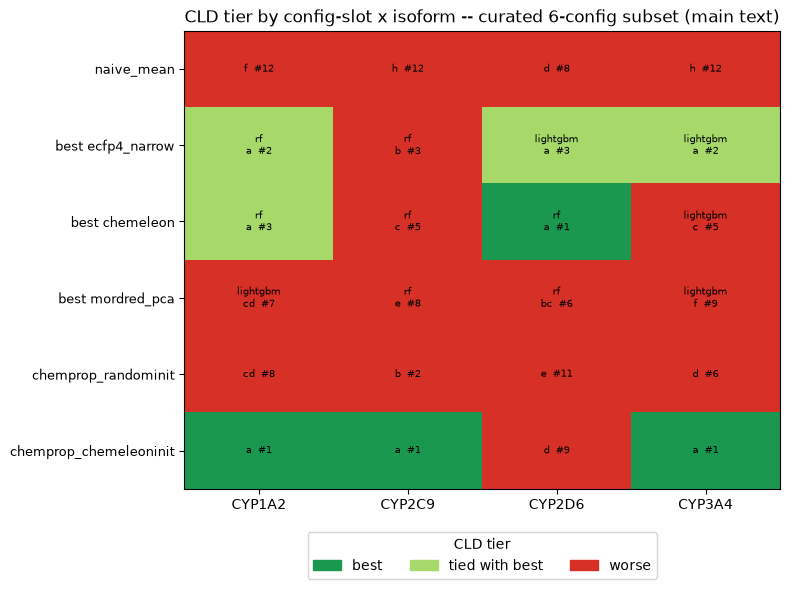

In [12]:
from matplotlib.colors import ListedColormap

TIER_CODE = {"best": 0, "tied with best": 1, "worse": 2}
tier_cmap = ListedColormap([TIER_COLORS["best"], TIER_COLORS["tied with best"], TIER_COLORS["worse"]])
SLOT_LABELS = ["naive_mean", "best ecfp4_narrow", "best chemeleon", "best mordred_pca", "chemprop_randominit", "chemprop_chemeleoninit"]

grid_codes = np.full((len(SLOT_LABELS), len(ISOFORM_COMPARISONS)), np.nan)
grid_text = [["" for _ in ISOFORM_COMPARISONS] for _ in SLOT_LABELS]

for j, comp_name in enumerate(ISOFORM_COMPARISONS):
    subset = curated_subset(comp_name)  # [naive_mean, ecfp4_winner, chemeleon_winner, mordred_winner, chemprop_randominit, chemprop_chemeleoninit]
    tiers, cld = config_tiers(comp_name)
    board = leaderboards[comp_name].reset_index(drop=True)
    rank = {cfg: i + 1 for i, cfg in enumerate(board["config"])}
    for i, cfg in enumerate(subset):
        grid_codes[i, j] = TIER_CODE[tiers[cfg]]
        algo = cfg.split("__")[1] if "__" in cfg else ""
        grid_text[i][j] = f"{algo}\n{cld[cfg]}  #{rank[cfg]}" if algo else f"{cld[cfg]}  #{rank[cfg]}"

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(grid_codes, cmap=tier_cmap, vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(len(ISOFORM_COMPARISONS)))
ax.set_xticklabels(ISOFORM_COMPARISONS)
ax.set_yticks(range(len(SLOT_LABELS)))
ax.set_yticklabels(SLOT_LABELS, fontsize=9)
for i in range(len(SLOT_LABELS)):
    for j in range(len(ISOFORM_COMPARISONS)):
        ax.text(j, i, grid_text[i][j], ha="center", va="center", fontsize=7)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=col, label=tier) for tier, col in TIER_COLORS.items()]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, title="CLD tier")
ax.set_title("CLD tier by config-slot x isoform -- curated 6-config subset (main text)")
fig.tight_layout()

grid_main_path = FIGURES_DIR / "cld_grid_ST-RAE_main.png"
fig.savefig(grid_main_path, dpi=150, bbox_inches="tight")
print(f"wrote {grid_main_path}")
plt.show()


**What this shows:** each row is a config "slot" from the curated 6-config subset
(the actual winning algorithm for the three tabular slots is printed inside the cell,
since it can differ by isoform), each column an isoform, color = CLD tier, text =
`{letter}  #{rank}`. Reading across a row shows how consistently that slot performs:
`chemprop_chemeleoninit`'s row is green/light-green for three isoforms and red for
CYP2D6 -- the same pattern the forest plot and Section 3's table both show, just
compressed into one glance. Reading down a column reproduces that isoform's own
leaderboard tier structure.


## Appendix

Full 12-config versions of the two headline figures above (Sections 4-5), plus the
pairwise ST-RAE heatmaps originally in this notebook's own Section 4 -- kept for
completeness / full-detail lookup, not needed to follow the main-text narrative.


### A. Full 12-config forest plot

Same `forest_panel` function as Section 4, called with the full config list for each
isoform comparison instead of the curated subset (MA is omitted here -- its full
config set is only 3, identical to the Section 4 panel already shown).


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/forest_ST-RAE_appendix_full12.png


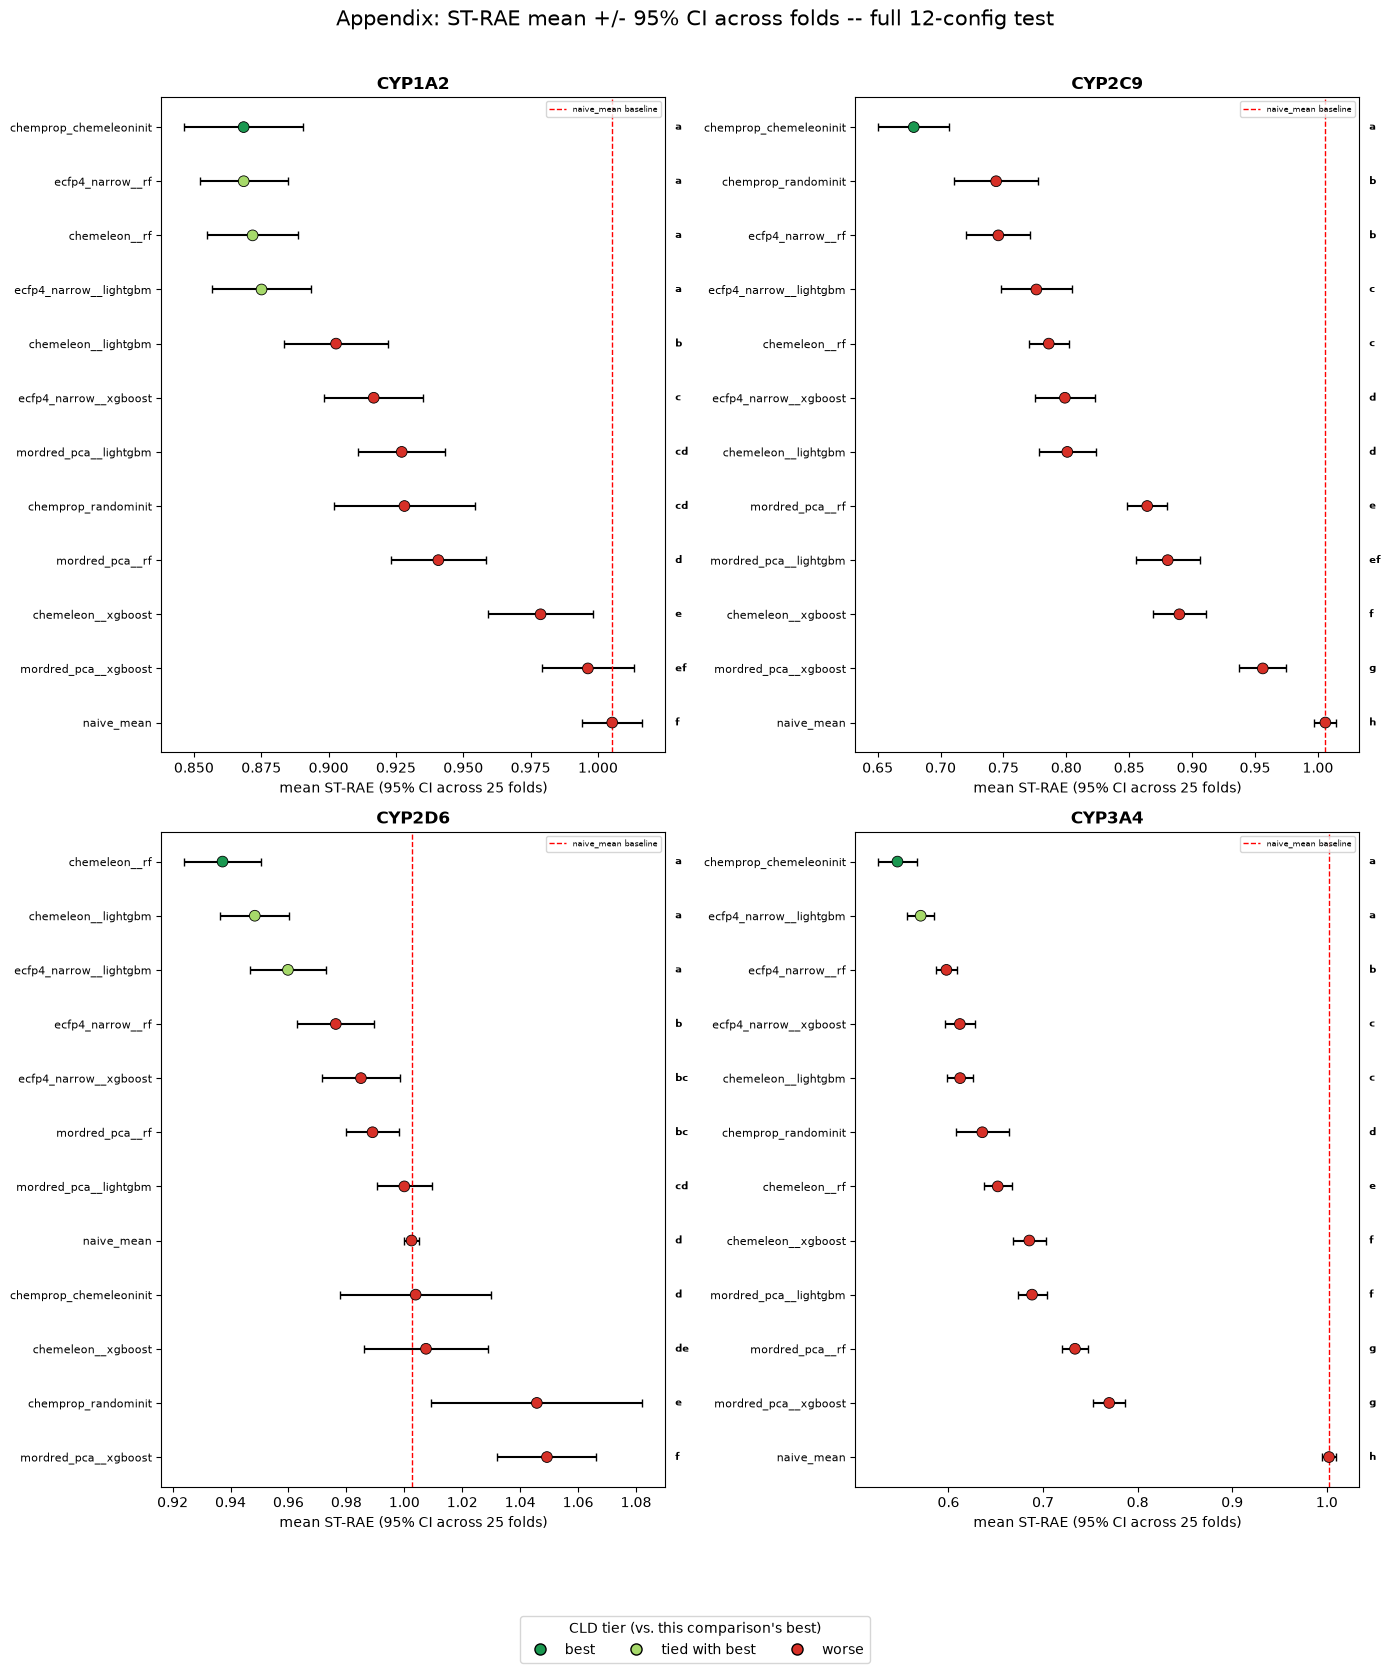

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
for ax, comp_name in zip(axes.flatten(), ISOFORM_COMPARISONS):
    forest_panel(ax, comp_name, COMPARISONS[comp_name]["configs"])

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=col, markeredgecolor="black", markersize=8, label=tier)
    for tier, col in TIER_COLORS.items()
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, title="CLD tier (vs. this comparison's best)")
fig.suptitle("Appendix: ST-RAE mean +/- 95% CI across folds -- full 12-config test", fontsize=15)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])

forest_appendix_path = FIGURES_DIR / "forest_ST-RAE_appendix_full12.png"
fig.savefig(forest_appendix_path, dpi=150, bbox_inches="tight")
print(f"wrote {forest_appendix_path}")
plt.show()


### B. Full 12-config CLD grid

Same idea as Section 5, but rows are the fixed, literal 12 configs (identical set
across all 4 isoform comparisons, by construction of `ISOFORM_COMPARISON_CONFIGS`) --
no "slot" ambiguity here, so no algorithm-name sub-label is needed in each cell.
`naive_mean`/`naive_median`-style baseline rows are italicized, matching
`04a_baseline_screen.ipynb` Section 6's own convention for its config x isoform grid.


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/figures/cld_grid_ST-RAE_appendix_full12.png


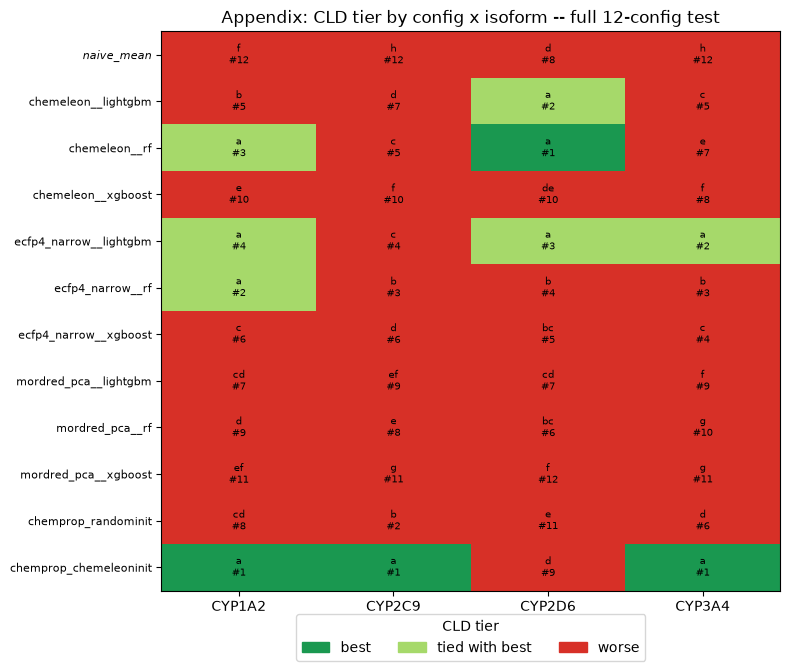

In [14]:
FULL_CONFIGS = COMPARISONS["CYP1A2"]["configs"]  # same 12 for all 4 isoform comparisons, by construction

grid_codes_full = np.full((len(FULL_CONFIGS), len(ISOFORM_COMPARISONS)), np.nan)
grid_text_full = [["" for _ in ISOFORM_COMPARISONS] for _ in FULL_CONFIGS]

for j, comp_name in enumerate(ISOFORM_COMPARISONS):
    tiers, cld = config_tiers(comp_name)
    board = leaderboards[comp_name].reset_index(drop=True)
    rank = {cfg: i + 1 for i, cfg in enumerate(board["config"])}
    for i, cfg in enumerate(FULL_CONFIGS):
        grid_codes_full[i, j] = TIER_CODE[tiers[cfg]]
        grid_text_full[i][j] = f"{cld[cfg]}\n#{rank[cfg]}"

fig, ax = plt.subplots(figsize=(8, 0.4 * len(FULL_CONFIGS) + 2))
ax.imshow(grid_codes_full, cmap=tier_cmap, vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(len(ISOFORM_COMPARISONS)))
ax.set_xticklabels(ISOFORM_COMPARISONS)
ax.set_yticks(range(len(FULL_CONFIGS)))
ax.set_yticklabels(FULL_CONFIGS, fontsize=8)
for i, name in enumerate(FULL_CONFIGS):
    if name.startswith("naive"):
        ax.get_yticklabels()[i].set_fontstyle("italic")  # matches 04a's own italic-naive convention
for i in range(len(FULL_CONFIGS)):
    for j in range(len(ISOFORM_COMPARISONS)):
        ax.text(j, i, grid_text_full[i][j], ha="center", va="center", fontsize=7)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=col, label=tier) for tier, col in TIER_COLORS.items()]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=3, title="CLD tier")
ax.set_title("Appendix: CLD tier by config x isoform -- full 12-config test")
fig.tight_layout()

grid_appendix_path = FIGURES_DIR / "cld_grid_ST-RAE_appendix_full12.png"
fig.savefig(grid_appendix_path, dpi=150, bbox_inches="tight")
print(f"wrote {grid_appendix_path}")
plt.show()


### C. Pairwise ST-RAE heatmaps

**Superseded for main-text purposes by the forest plot in Section 4** -- relocated
here unchanged (same code, same reuse-only logic: `results[(comparison,
"ST-RAE")]["means"]`/`["pairwise_p"]` from Section 2 and `leaderboards[comparison]`'s
order from Section 3, nothing recomputed). Still useful as a full-detail complement:
the forest plot's tier coloring only shows each config's relationship to *that
comparison's best*, while this view gives the exact pairwise difference and
significance star between *any two* configs directly.

Layout follows Ash Figure 8's own "multiple comparisons similarity" (MCSim) plot --
one grid of square heatmaps, axis ticks labeled `{config}\n{mean ST-RAE}`, diagonal
reading `0.0`, `**` marking pairs whose already-computed corrected p-value is below
0.05 (the same threshold driving the CLD letters above -- no new significance rule
introduced).

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/05_cv_comparison/pairwise_heatmaps_ST-RAE.png


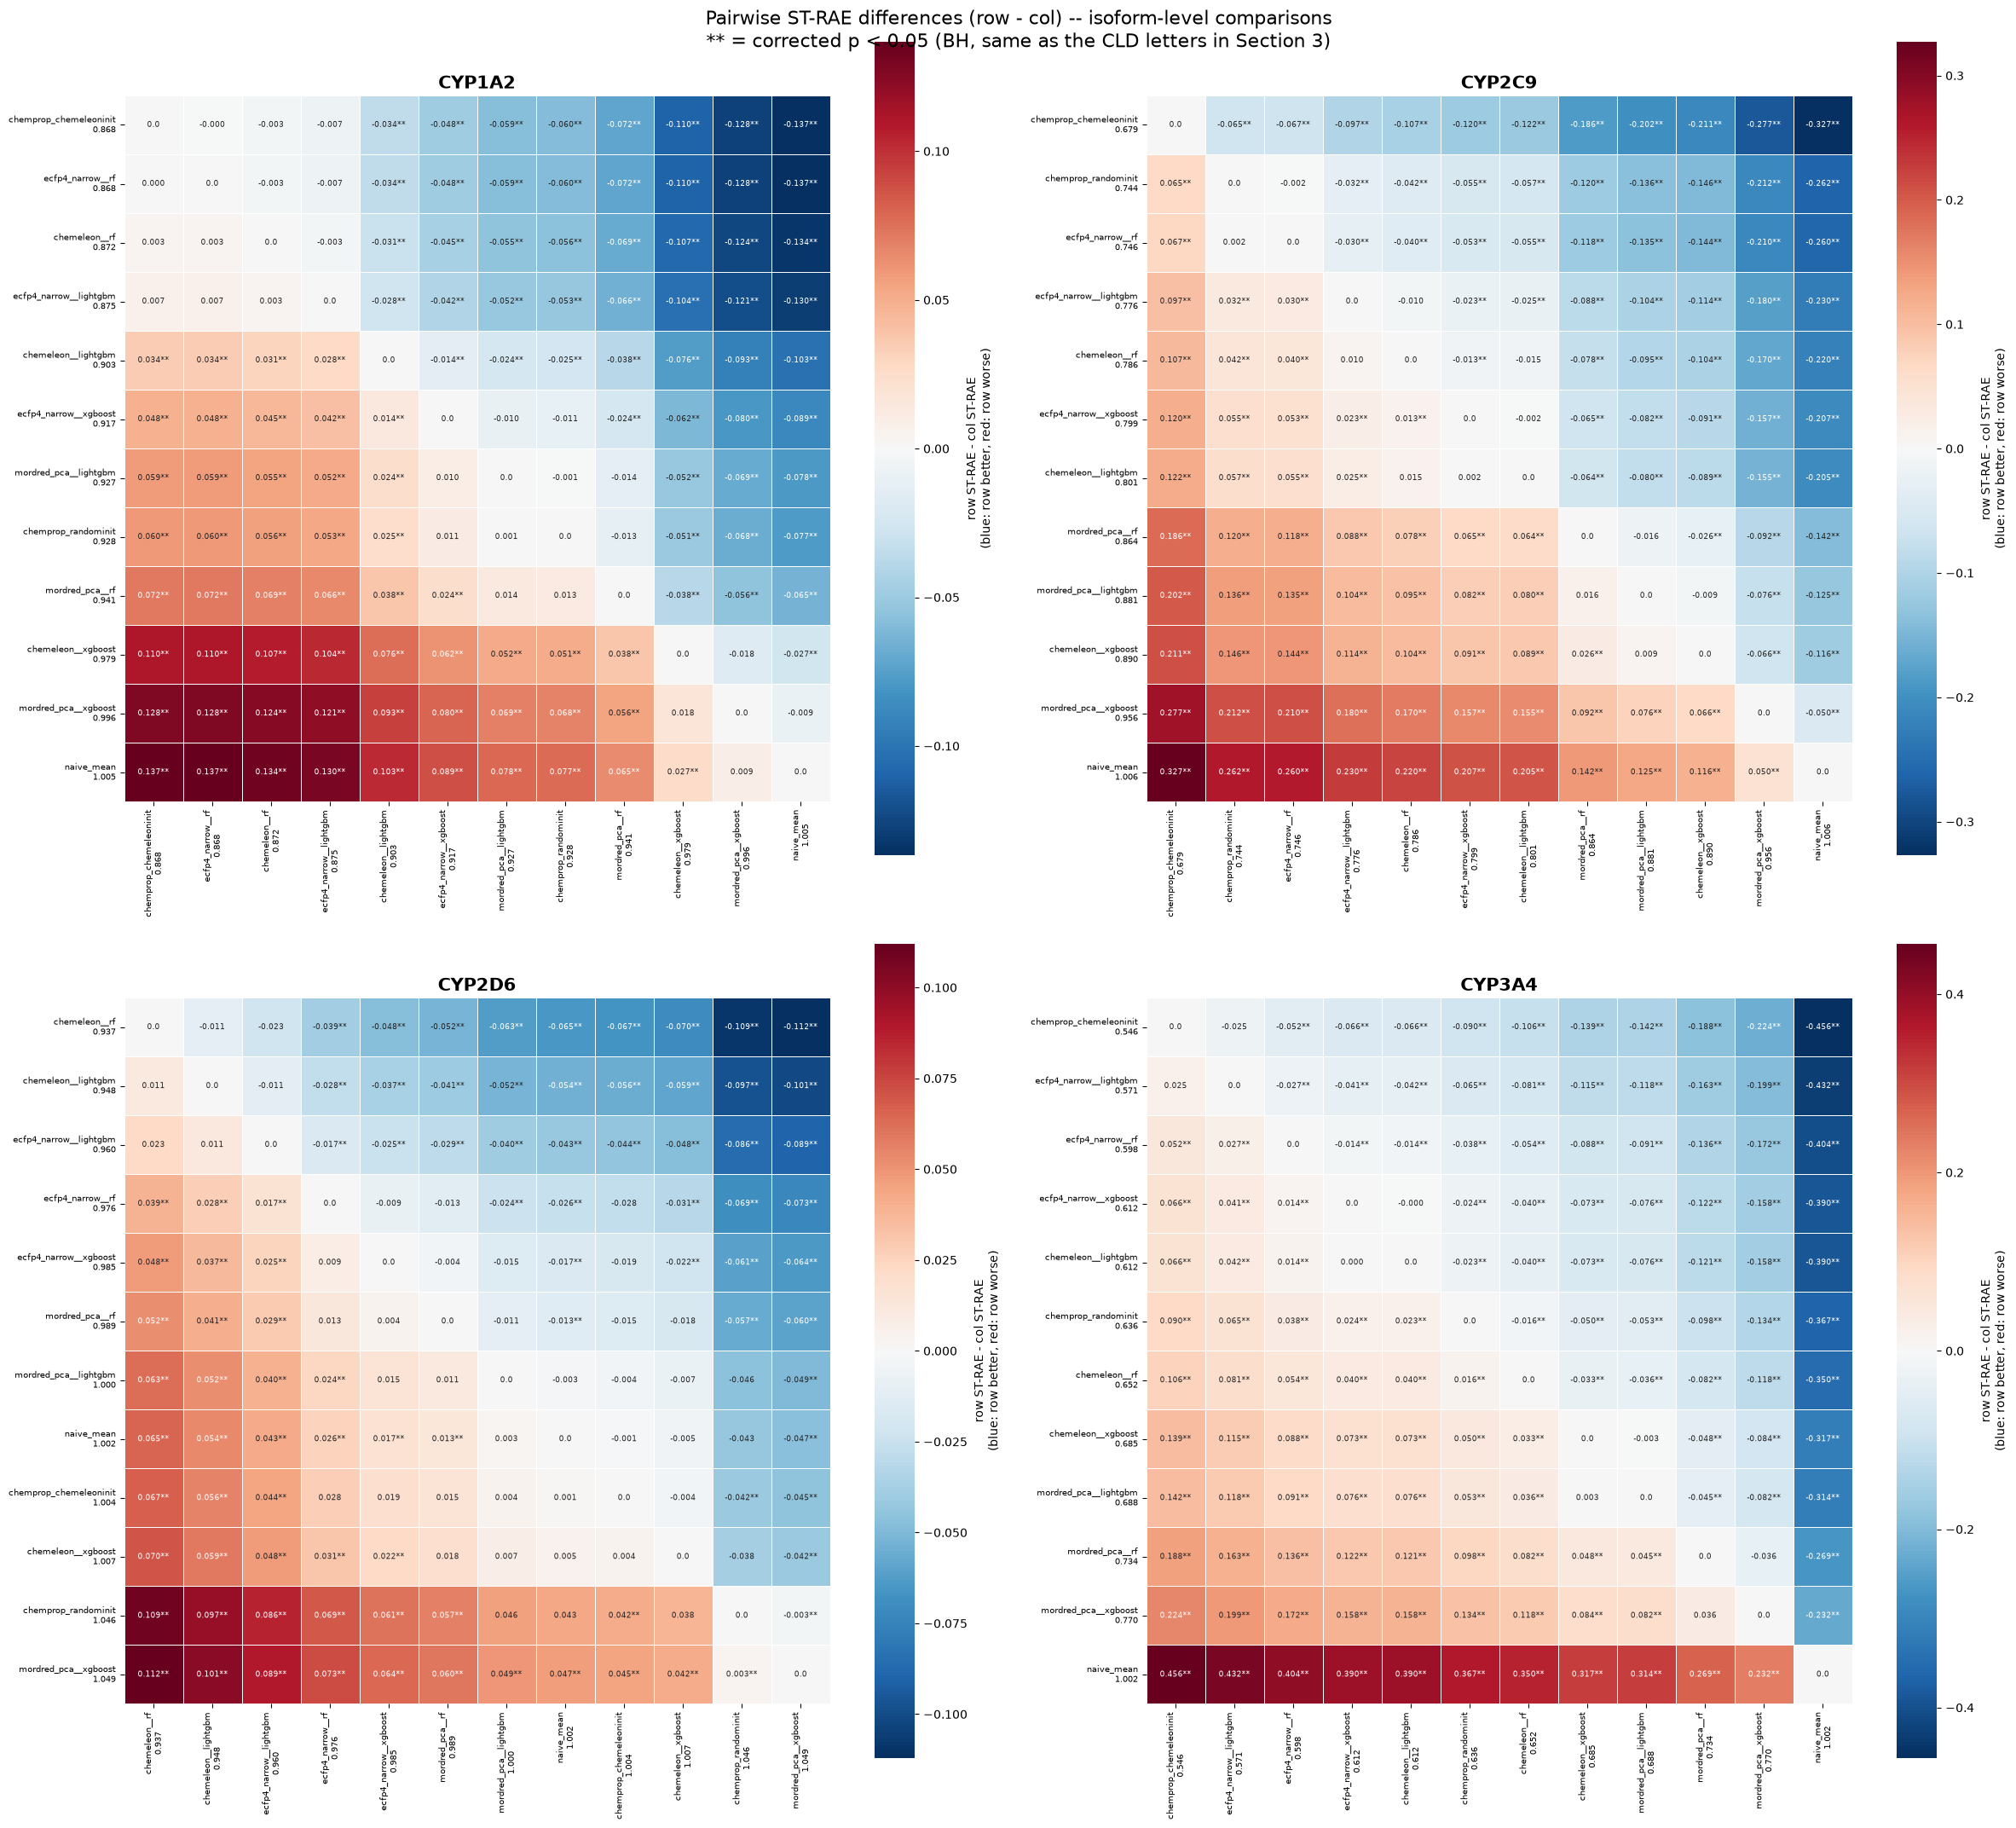

In [15]:
import seaborn as sns

ISOFORM_COMPARISONS = [c for c in COMPARISONS if c != MACRO_ENDPOINT_LABEL]  # CYP1A2, CYP2C9, CYP2D6, CYP3A4 -- MA excluded

fig, axes = plt.subplots(2, 2, figsize=(24, 22))

for ax, comp_name in zip(axes.flatten(), ISOFORM_COMPARISONS):
    st_rae = results[(comp_name, "ST-RAE")]
    means, pairwise_p = st_rae["means"], st_rae["pairwise_p"]
    order = leaderboards[comp_name]["config"].tolist()  # already best-to-worst by ST-RAE, from Section 3 -- reused, not recomputed

    diff_matrix = pd.DataFrame(index=order, columns=order, dtype=float)
    annot_matrix = pd.DataFrame(index=order, columns=order, dtype=object)
    for row_cfg in order:
        for col_cfg in order:
            if row_cfg == col_cfg:
                diff_matrix.loc[row_cfg, col_cfg] = 0.0
                annot_matrix.loc[row_cfg, col_cfg] = "0.0"
            else:
                diff = means[row_cfg] - means[col_cfg]
                diff_matrix.loc[row_cfg, col_cfg] = diff
                significant = pairwise_p.loc[row_cfg, col_cfg] < ALPHA  # same alpha driving the CLD letters
                annot_matrix.loc[row_cfg, col_cfg] = f"{diff:.3f}" + ("**" if significant else "")

    tick_labels = [f"{cfg}\n{means[cfg]:.3f}" for cfg in order]
    vlim = float(np.abs(diff_matrix.to_numpy()).max())  # symmetric range around 0, from largest magnitude difference

    sns.heatmap(
        diff_matrix, annot=annot_matrix.to_numpy(), fmt="", cmap="RdBu_r", center=0, vmin=-vlim, vmax=vlim,
        xticklabels=tick_labels, yticklabels=tick_labels, ax=ax, square=True, linewidths=0.5, linecolor="white",
        annot_kws={"size": 6.5},
        cbar_kws={"label": "row ST-RAE - col ST-RAE\n(blue: row better, red: row worse)"},
    )
    ax.set_title(comp_name, fontsize=15, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)

fig.suptitle(
    "Pairwise ST-RAE differences (row - col) -- isoform-level comparisons\n"
    "** = corrected p < 0.05 (BH, same as the CLD letters in Section 3)",
    fontsize=16,
)
plt.tight_layout()

heatmap_path = OUT / "pairwise_heatmaps_ST-RAE.png"
fig.savefig(heatmap_path, dpi=150, bbox_inches="tight")
print(f"wrote {heatmap_path}")
plt.show()


**How to read this:** each cell is `row config`'s mean ST-RAE minus `column config`'s
mean ST-RAE, for the same 25 folds. Since ST-RAE is an error metric (lower is better,
same direction as the CLD sort in Section 3), a **blue** cell means the row config has
*lower* ST-RAE than the column config -- the row is better -- and a **red** cell means
the row is worse; the colorbar label states this explicitly per subplot, since the
same red/blue-for-positive/negative convention would mean the opposite for a
higher-is-better metric like R2. `**` marks pairs whose already-computed corrected
p-value is below 0.05 -- the identical test and threshold behind the CLD letters
above, not a new one -- so every `**` cell here is exactly a pair that landed in
different CLD letter groups, and every unstarred off-diagonal cell is a pair sharing a
letter. Reading down any row shows that config's full head-to-head record; reading the
top row of each panel (the best-ST-RAE config, per the axis order) shows how far
behind every other config actually is, with a direct sense of both the size of the gap
(color intensity) and whether it's statistically real (`**`).
